# DataBento MBO: Multi-Day Bar Calibration Study

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Calibrate bar-sampling parameters across 10 trading days of NVDA MBO data,
something single-day ITCH samples can't support. The study answers: how
does daily volume variability translate to bar-count instability, and how
robust are imbalance-bar parameters across market conditions?

## Learning Objectives

After completing this notebook, you will be able to:
- Load and process multi-day MBO trade data efficiently with polars
  streaming.
- Quantify day-to-day volume variability and its impact on fixed-threshold
  bar counts.
- Calibrate dollar / volume / imbalance bar thresholds for a target daily
  bar count.
- Recommend production-ready calibration methodology grounded in the
  per-day diagnostics.

## Book reference

Section §3.4, *The Art of Sampling* — multi-day calibration paragraph
referencing fixed-threshold imbalance bars.

## Prerequisites

- DataBento XNAS-ITCH MBO parquets at
  `data/equities/market/microstructure/market_by_order/NVDA/` (10 trading
  days, November 2024).

---

## 1. Setup

In [1]:
"""DataBento MBO: Multi-Day Bar Calibration Study — calibrating bar sampling parameters across trading days."""

import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# ML4T imports - path resolution
# Import loader for MBO data
from data import load_mbo_data
from utils.paths import get_output_dir

In [2]:
# Production defaults — Papermill injects overrides for CI
N_DAYS = 10  # Number of trading days to analyze
MAX_ROWS_PER_DAY = 0  # 0 = all rows

In [3]:
# Style configuration
sns.set_style("whitegrid")

# Polars display config

In [4]:
# Directories and configuration
OUTPUT_DIR = get_output_dir(3, "databento")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SYMBOL = "NVDA"
# Get file paths from the canonical loader (handles legacy/new path resolution)
data_files = load_mbo_data(symbols=[SYMBOL], list_files=True)
SYMBOL_DATA_DIR = data_files[0].parent if data_files else None

# Multi-day configuration
TARGET_BARS_PER_DAY = 500  # ~1 bar per minute of RTH (6.5 hours)
THRESHOLD_LABEL_FMTS = {
    "time": lambda t: f"{int(t)}m",
    "tick": lambda t: f"{int(t):,}",
    "volume": lambda t: f"{int(t / 1000)}K",
    "dollar": lambda t: f"${int(t / 1000)}K",
}

# Normalize MAX_ROWS_PER_DAY: 0 means no limit
if MAX_ROWS_PER_DAY == 0:
    MAX_ROWS_PER_DAY = None

## 2. Multi-Day Data Loading

Load trade data from multiple days and prepare for calibration analysis.
We filter to Regular Trading Hours (RTH: 9:30-16:00 ET = 13:30-21:00 UTC).

### Load Single-Day Trades

Parse one parquet file into RTH trades with aggressor side classification.

In [5]:
def _load_day_trades(file_path: Path, max_rows_per_day: int | None = None) -> pl.DataFrame:
    """Load and process trades from a single daily parquet file.

    Filters to Regular Trading Hours (09:30-16:00 America/New_York) and maps the
    aggressor side from DataBento's Trade-record convention.
    """
    # Derive the date from the trailing 8-digit token so both file layouts work:
    # Download Center `xnas-itch-YYYYMMDD.mbo.dbn.parquet` and API `YYYYMMDD.parquet`.
    date_str = re.search(r"(\d{8})", file_path.stem).group(1)
    trade_date = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]}"

    # Load raw MBO data
    df = pl.read_parquet(file_path)

    # Normalize the event-time column name (API files use `ts_event`).
    if "timestamp" not in df.columns and "ts_event" in df.columns:
        df = df.rename({"ts_event": "timestamp"})

    # Select columns
    df = df.select(["timestamp", "action", "side", "price", "size"])

    # Cast timestamp (UTC; kept naive for downstream)
    df = df.with_columns(pl.col("timestamp").cast(pl.Datetime("ns")))

    # Filter to trades only (action == 'T')
    df = df.filter(pl.col("action") == "T")

    # Regular trading hours (09:30-16:00 America/New_York). Convert the UTC instant
    # to exchange-local time so the window is correct in both EDT and EST rather
    # than admitting an hour of pre-market as a fixed UTC window does.
    _et = pl.col("timestamp").dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York")
    df = df.filter(
        ((_et.dt.hour() > 9) | ((_et.dt.hour() == 9) & (_et.dt.minute() >= 30)))
        & (_et.dt.hour() < 16)
    )

    # Add date column
    df = df.with_columns(pl.lit(trade_date).alias("date"))

    # Aggressor side for Trade (T) records: DataBento sets `side` to the trade
    # aggressor — B = buy-initiated (+1), A = sell-initiated (-1), N = unknown (0).
    # (The resting-order interpretation applies to Fill `F` records, not `T`.)
    df = df.with_columns(
        pl.when(pl.col("side") == "B")
        .then(1)
        .when(pl.col("side") == "A")
        .then(-1)
        .otherwise(0)
        .alias("side_num")
    )

    # Select final columns
    df = df.select(
        [
            "timestamp",
            "date",
            pl.col("price"),
            pl.col("size").alias("volume"),
            pl.col("side_num").alias("side"),
        ]
    )

    if max_rows_per_day is not None:
        df = df.head(max_rows_per_day)

    return df

### Combine Multi-Day Trades

Discover daily files, load each via the helper, and concatenate into a single DataFrame.

In [6]:
def load_multiday_trades(
    data_dir: Path, n_days: int, max_rows_per_day: int | None = None
) -> pl.DataFrame:
    """Load trade data from multiple days.

    Parameters
    ----------
    data_dir : Path
        Directory containing daily parquet files
    n_days : int
        Number of trading days to load
    max_rows_per_day : int, optional
        Limit rows per day (for testing)

    Returns
    -------
    pl.DataFrame
        Combined trades with columns: timestamp, date (str), price, volume, side
    """
    data_files = sorted(data_dir.glob("*.parquet"))[:n_days]

    if not data_files:
        print(f"No data files found in {data_dir}")
        return pl.DataFrame()

    all_trades = []

    for file_path in data_files:
        df = _load_day_trades(file_path, max_rows_per_day)
        all_trades.append(df)
        # Extract date for logging from the loaded frame
        trade_date = df["date"][0] if len(df) > 0 else file_path.name
        print(f"  {trade_date}: {len(df):,} trades")

    if not all_trades:
        return pl.DataFrame()

    combined = pl.concat(all_trades).sort(["date", "timestamp"])
    print(f"\nTotal: {len(combined):,} trades across {len(all_trades)} days")

    return combined

In [7]:
# Load multi-day trade data
print(f"Loading {N_DAYS} days of {SYMBOL} trade data...\n")
trades = load_multiday_trades(SYMBOL_DATA_DIR, n_days=N_DAYS, max_rows_per_day=MAX_ROWS_PER_DAY)

if len(trades) == 0:
    print("No trade data loaded. Check data directory.")
    trades = None

Loading 10 days of NVDA trade data...

  2024-11-04: 195,420 trades


  2024-11-05: 170,851 trades
  2024-11-06: 310,220 trades
  2024-11-07: 221,892 trades


  2024-11-08: 191,773 trades
  2024-11-11: 267,686 trades


  2024-11-12: 257,341 trades
  2024-11-13: 237,090 trades


  2024-11-14: 260,466 trades
  2024-11-15: 326,376 trades



Total: 2,439,115 trades across 10 days


## 3. Daily Volume Profile

Before calibrating bar thresholds, we need to understand the day-to-day
variability in trading activity. This justifies why single-day calibration
is insufficient.

In [8]:
if trades is not None and len(trades) > 0:
    # Compute daily statistics
    daily_stats = (
        trades.group_by("date")
        .agg(
            [
                pl.len().alias("trade_count"),
                pl.col("volume").sum().alias("total_volume"),
                (pl.col("price") * pl.col("volume")).sum().alias("dollar_volume"),
                pl.col("price").mean().alias("avg_price"),
            ]
        )
        .sort("date")
    )

    # Add derived metrics
    daily_stats = daily_stats.with_columns(
        [
            (pl.col("dollar_volume") / 1e6).alias("dollar_volume_M"),
            (pl.col("total_volume") / 1e6).alias("volume_M"),
        ]
    )

    print("=== Daily Trading Profile ===\n")
    print(daily_stats.select(["date", "trade_count", "volume_M", "dollar_volume_M"]))

    # Compute variability metrics
    cv_trades = daily_stats["trade_count"].std() / daily_stats["trade_count"].mean()
    cv_volume = daily_stats["total_volume"].std() / daily_stats["total_volume"].mean()
    cv_dollar = daily_stats["dollar_volume"].std() / daily_stats["dollar_volume"].mean()

    print("\n=== Day-to-Day Variability (CV = StdDev/Mean) ===")
    print(f"  Trade count CV: {cv_trades:.2%}")
    print(f"  Volume CV:      {cv_volume:.2%}")
    print(f"  Dollar volume CV: {cv_dollar:.2%}")
    print("\nConclusion: ~20-40% daily variability means single-day calibration is unreliable.")

=== Daily Trading Profile ===

shape: (10, 4)
┌────────────┬─────────────┬───────────┬─────────────────┐
│ date       ┆ trade_count ┆ volume_M  ┆ dollar_volume_M │
│ ---        ┆ ---         ┆ ---       ┆ ---             │
│ str        ┆ u32         ┆ f64       ┆ f64             │
╞════════════╪═════════════╪═══════════╪═════════════════╡
│ 2024-11-04 ┆ 195420      ┆ 21.285061 ┆ 2923.766835     │
│ 2024-11-05 ┆ 170851      ┆ 19.06341  ┆ 2654.195002     │
│ 2024-11-06 ┆ 310220      ┆ 34.639802 ┆ 5007.684313     │
│ 2024-11-07 ┆ 221892      ┆ 25.741796 ┆ 3807.45437      │
│ 2024-11-08 ┆ 191773      ┆ 20.6897   ┆ 3056.834995     │
│ 2024-11-11 ┆ 267686      ┆ 25.572074 ┆ 3726.294942     │
│ 2024-11-12 ┆ 257341      ┆ 25.000182 ┆ 3699.383371     │
│ 2024-11-13 ┆ 237090      ┆ 23.003062 ┆ 3387.960487     │
│ 2024-11-14 ┆ 260466      ┆ 27.024491 ┆ 3985.294133     │
│ 2024-11-15 ┆ 326376      ┆ 34.280567 ┆ 4894.904583     │
└────────────┴─────────────┴───────────┴─────────────────┘

=== Day-t

## 4. Bar Samplers

Import the vectorized bar samplers from ml4t.engineer.bars.

In [9]:
# Import bar samplers
from ml4t.engineer.bars import (
    DollarBarSampler,
    ImbalanceBarSampler,
    TickBarSampler,
    TickImbalanceBarSampler,
    VolumeBarSampler,
)

print("Bar samplers imported successfully")

Bar samplers imported successfully


## 5. Calibration Functions

Define functions to build bars and compute statistics for calibration.

### Time Bar Construction

Build OHLCV bars by grouping trades into fixed time intervals.

In [10]:
def _build_time_bars(day_trades: pl.DataFrame, threshold: float) -> pl.DataFrame:
    """Aggregate trades into time bars using group_by_dynamic."""
    return (
        day_trades.group_by_dynamic("timestamp", every=f"{int(threshold)}m")
        .agg(
            [
                pl.col("price").first().alias("open"),
                pl.col("price").max().alias("high"),
                pl.col("price").min().alias("low"),
                pl.col("price").last().alias("close"),
                pl.col("volume").sum().alias("volume"),
                pl.len().alias("tick_count"),
            ]
        )
        .filter(pl.col("volume") > 0)
    )

### Imbalance Bar Construction

Filter trades to those with known aggressor side and build imbalance bars.

In [11]:
def _build_imbalance_bars(
    day_trades: pl.DataFrame, bar_type: str, threshold: float, alpha: float
) -> pl.DataFrame | None:
    """Build volume or tick imbalance bars from trades with known side.

    Returns None if fewer than 50% of trades have a classified side.
    """
    usable = day_trades.filter(pl.col("side") != 0)
    if len(usable) < len(day_trades) * 0.5:
        return None

    if bar_type == "imbalance":
        # Volume Imbalance Bars (VIBs): θ = Σ b_t × v_t
        sampler = ImbalanceBarSampler(expected_ticks_per_bar=int(threshold), alpha=alpha)
    else:
        # Tick Imbalance Bars (TIBs): θ = Σ b_t
        sampler = TickImbalanceBarSampler(expected_ticks_per_bar=int(threshold), alpha=alpha)

    return sampler.sample(usable)

### Build Bars for a Day

Dispatch to the appropriate bar sampler for one trading day.

In [12]:
def build_bars_for_day(
    day_trades: pl.DataFrame,
    bar_type: str,
    threshold: float,
    alpha: float = 0.1,
) -> pl.DataFrame | None:
    """Build bars for a single day with given parameters.

    Parameters
    ----------
    day_trades : pl.DataFrame
        Trades for one day (timestamp, price, volume, side)
    bar_type : str
        One of: 'time', 'tick', 'volume', 'dollar', 'imbalance', 'tick_imbalance'
    threshold : float
        Bar threshold (meaning depends on bar_type)
    alpha : float
        EWMA alpha for imbalance bars

    Returns
    -------
    pl.DataFrame or None
        OHLCV bars or None if insufficient data
    """
    if len(day_trades) < 100:
        return None

    try:
        if bar_type == "time":
            bars = _build_time_bars(day_trades, threshold)
        elif bar_type == "tick":
            sampler = TickBarSampler(ticks_per_bar=int(threshold))
            bars = sampler.sample(day_trades)
        elif bar_type == "volume":
            sampler = VolumeBarSampler(volume_per_bar=threshold)
            bars = sampler.sample(day_trades)
        elif bar_type == "dollar":
            sampler = DollarBarSampler(dollars_per_bar=threshold)
            bars = sampler.sample(day_trades)
        elif bar_type in ("imbalance", "tick_imbalance"):
            bars = _build_imbalance_bars(day_trades, bar_type, threshold, alpha)
            if bars is None:
                return None
        else:
            raise ValueError(f"Unknown bar_type: {bar_type}")

        return bars if len(bars) > 10 else None

    except Exception as e:
        print(f"Error building {bar_type} bars: {e}")
        return None

### Compute Bar Statistics

Compute statistical properties (normality, autocorrelation, variance ratio) for bar returns.

In [13]:
def compute_bar_statistics(bars: pl.DataFrame) -> dict | None:
    """Compute statistical properties for bar returns.

    Metrics explained:
    - **Jarque-Bera (JB)**: Tests deviation from normality. Lower = more normal.
      JB=0 is perfectly normal; higher values indicate fat tails/skewness.
      Event-driven bars typically show lower JB than time bars.

    - **Autocorrelation(1)**: Correlation of r(t) with r(t-1). Should be ~0
      for efficient markets. High values suggest predictability or microstructure effects.

    - **Skewness**: Asymmetry of return distribution. 0 = symmetric.
      Negative skew (fat left tail) is common in equity returns.

    - **Kurtosis**: Tail weight (excess kurtosis, 0 = normal). Positive values
      indicate fat tails. Financial returns typically show kurtosis > 0.

    - **Variance Ratio VR(q)**: Var(q-period returns) / (q × Var(1-period returns)).
      Under random walk, VR(q) = 1. VR > 1 = momentum; VR < 1 = mean reversion.

    Returns
    -------
    dict or None
        Dictionary of statistics or None if insufficient data
    """
    if bars is None or len(bars) < 30:
        return None

    closes = bars["close"].to_numpy()
    returns = np.diff(np.log(closes))
    returns = returns[~np.isnan(returns) & ~np.isinf(returns)]

    if len(returns) < 20:
        return None

    # Jarque-Bera test
    jb_stat, jb_pval = stats.jarque_bera(returns)

    # Moments
    skewness = stats.skew(returns)
    kurtosis = stats.kurtosis(returns)  # Excess kurtosis

    # Lag-1 autocorrelation
    autocorr = np.corrcoef(returns[:-1], returns[1:])[0, 1]

    # Variance Ratio VR(5) - tests random walk
    # VR(q) = Var(r_t + ... + r_{t+q-1}) / (q * Var(r_t))
    # Under random walk, VR(q) = 1
    q = 5
    if len(returns) > q * 2:
        # Multi-period returns
        multi_returns = np.array([np.sum(returns[i : i + q]) for i in range(len(returns) - q + 1)])
        var_ratio = np.var(multi_returns) / (q * np.var(returns))
    else:
        var_ratio = np.nan

    return {
        "n_bars": len(bars),
        "jb_stat": jb_stat,
        "jb_pval": jb_pval,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "autocorr": autocorr,
        "var_ratio": var_ratio,
        "mean_ret": np.mean(returns) * 100,
        "std_ret": np.std(returns) * 100,
    }

## 6. Calibration Experiment

Run the calibration experiment across all days and bar types.
We test multiple thresholds to find those producing ~500 bars/day.

In [14]:
# Define calibration grid
# NVDA trades ~$6-10B/day, so need $10-20M thresholds for ~500 bars
CALIBRATION_GRID = {
    "time": [1, 2, 5, 10],  # minutes
    "tick": [500, 1000, 2000, 4000],
    "volume": [25_000, 50_000, 100_000, 200_000],
    "dollar": [5_000_000, 10_000_000, 15_000_000, 25_000_000],
}
# Information bars calibration
# Critical: Use slow adaptation (α=0.001) to prevent threshold spiral
# with persistent order flow imbalance (NVDA ~52-60% buys)

# Volume Imbalance Bars (VIBs): θ = Σ b_t × v_t
# Threshold: E[T] × |2v⁺ - E[v]|
VIB_EXPECTED_T = [5_000, 10_000, 20_000, 50_000]

# Tick Imbalance Bars (TIBs): θ = Σ b_t
# Threshold: E[T] × |2P[b=1] - 1|
# TIBs produce ~800x more bars than VIBs at same E[T]
TIB_EXPECTED_T = [500, 1_000, 2_000, 3_000]

# Shared parameters - SLOW adaptation to prevent threshold spiral
IMBALANCE_ALPHA = [0.001]  # Not 0.1! Prevents feedback loop
IMBALANCE_WARMUP = 100  # Longer warmup for stable initialization

In [15]:
if trades is not None and len(trades) > 0:
    print("=== Running Calibration Experiment ===\n")

    # Get unique dates
    dates = trades["date"].unique().sort().to_list()

    # Storage for results (accumulates across cells)
    calibration_results = []
    stats_results = []

=== Running Calibration Experiment ===



In [16]:
if trades is not None and len(trades) > 0:
    for bar_type, thresholds in CALIBRATION_GRID.items():
        print(f"\n{bar_type.upper()} bars:")

        for threshold in thresholds:
            for date in dates:
                day_trades = trades.filter(pl.col("date") == date).drop("date")
                bars = build_bars_for_day(day_trades, bar_type, threshold)

                if bars is not None:
                    bar_stats = compute_bar_statistics(bars)
                    calibration_results.append(
                        {
                            "bar_type": bar_type,
                            "threshold": str(threshold),
                            "threshold_num": float(threshold),
                            "date": date,
                            "n_bars": len(bars),
                            "expected_t": None,
                            "alpha": None,
                        }
                    )
                    if bar_stats:
                        bar_stats["bar_type"] = bar_type
                        bar_stats["threshold"] = str(threshold)
                        bar_stats["date"] = date
                        stats_results.append(bar_stats)

            # Summary for this threshold
            threshold_bars = [
                r["n_bars"]
                for r in calibration_results
                if r["bar_type"] == bar_type and r["threshold"] == str(threshold)
            ]
            if threshold_bars:
                print(
                    f"  {threshold:>12}: {np.mean(threshold_bars):>6.0f} bars/day "
                    f"(±{np.std(threshold_bars):.0f})"
                )


TIME bars:
             1:    390 bars/day (±0)


             2:    195 bars/day (±0)


             5:     78 bars/day (±0)
            10:     39 bars/day (±0)

TICK bars:


           500:    487 bars/day (±96)
          1000:    243 bars/day (±48)


          2000:    121 bars/day (±24)
          4000:     60 bars/day (±12)

VOLUME bars:


         25000:    912 bars/day (±156)
         50000:    462 bars/day (±79)
        100000:    232 bars/day (±40)


        200000:    117 bars/day (±20)

DOLLAR bars:
       5000000:    665 bars/day (±118)


      10000000:    336 bars/day (±59)
      15000000:    225 bars/day (±40)


      25000000:    135 bars/day (±24)


### Imbalance Bar Single-Day Helper
Process one day of trades for a given imbalance bar configuration, appending results.

In [17]:
def _process_imbalance_day(
    day_trades, date, sampler_cls, expected_t, alpha, bar_type_name, tkey, cal_results, stat_results
):
    """Sample imbalance bars for one day and record calibration + stat results."""
    known = day_trades.filter(pl.col("side") != 0)
    if len(known) < 1000:
        return
    try:
        sampler = sampler_cls(
            expected_ticks_per_bar=expected_t,
            alpha=alpha,
            min_bars_warmup=IMBALANCE_WARMUP,
        )
        bars = sampler.sample(known)
    except Exception:
        bars = None
    if bars is not None and len(bars) > 10:
        bar_stats = compute_bar_statistics(bars)
        cal_results.append(
            {
                "bar_type": bar_type_name,
                "threshold": tkey,
                "threshold_num": float(expected_t),
                "date": date,
                "n_bars": len(bars),
                "expected_t": expected_t,
                "alpha": alpha,
            }
        )
        if bar_stats:
            bar_stats.update(
                {
                    "bar_type": bar_type_name,
                    "threshold": tkey,
                    "date": date,
                    "expected_t": expected_t,
                    "alpha": alpha,
                }
            )
            stat_results.append(bar_stats)

### Imbalance Bar Calibration Sweep
Run calibration sweep for a single imbalance bar type across thresholds and alphas.

In [18]:
def _calibrate_imbalance_bars(
    trades_df,
    dates,
    expected_t_list,
    alpha_list,
    sampler_cls,
    bar_type_name,
    cal_results,
    stat_results,
):
    """Run calibration sweep for one imbalance bar type."""
    for expected_t in expected_t_list:
        for alpha in alpha_list:
            tkey = f"E[T]={expected_t},α={alpha}"
            for date in dates:
                day = trades_df.filter(pl.col("date") == date).drop("date")
                _process_imbalance_day(
                    day,
                    date,
                    sampler_cls,
                    expected_t,
                    alpha,
                    bar_type_name,
                    tkey,
                    cal_results,
                    stat_results,
                )
            bars_et = [
                r["n_bars"]
                for r in cal_results
                if r["bar_type"] == bar_type_name and r.get("expected_t") == expected_t
            ]
            if bars_et:
                print(
                    f"  E[T]={expected_t:>5}: {np.mean(bars_et):>6.0f} bars/day "
                    f"(±{np.std(bars_et):.0f})"
                )

In [19]:
if trades is not None and len(trades) > 0:
    print("\nTICK IMBALANCE BARS (TIBs):")
    print("  Formula: θ = Σ b_t (accumulate signed ticks)")
    _calibrate_imbalance_bars(
        trades,
        dates,
        TIB_EXPECTED_T,
        IMBALANCE_ALPHA,
        TickImbalanceBarSampler,
        "tick_imbalance",
        calibration_results,
        stats_results,
    )


TICK IMBALANCE BARS (TIBs):
  Formula: θ = Σ b_t (accumulate signed ticks)


  E[T]=  500:  42399 bars/day (±65705)


  E[T]= 1000:  10696 bars/day (±20781)
  E[T]= 2000:    288 bars/day (±356)


  E[T]= 3000:    208 bars/day (±316)


In [20]:
if trades is not None and len(trades) > 0:
    print("\nVOLUME IMBALANCE BARS (VIBs):")
    print("  Formula: θ = Σ b_t × v_t (accumulate signed volume)")
    _calibrate_imbalance_bars(
        trades,
        dates,
        VIB_EXPECTED_T,
        IMBALANCE_ALPHA,
        ImbalanceBarSampler,
        "volume_imbalance",
        calibration_results,
        stats_results,
    )


VOLUME IMBALANCE BARS (VIBs):
  Formula: θ = Σ b_t × v_t (accumulate signed volume)


  E[T]= 5000:     82 bars/day (±71)


  E[T]=10000:     82 bars/day (±95)


  E[T]=20000:     88 bars/day (±58)
  E[T]=50000:     50 bars/day (±22)


In [21]:
if trades is not None and len(trades) > 0:
    calibration_df = pl.DataFrame(
        calibration_results,
        schema={
            "bar_type": pl.Utf8,
            "threshold": pl.Utf8,
            "threshold_num": pl.Float64,
            "date": pl.Utf8,
            "n_bars": pl.Int64,
            "expected_t": pl.Int64,
            "alpha": pl.Float64,
        },
    )
    stats_df = pl.DataFrame(stats_results)

    print(f"\nTotal calibration runs: {len(calibration_df):,}")
    print(f"Statistical analysis runs: {len(stats_df):,}")


Total calibration runs: 221
Statistical analysis runs: 209


## 7. Visualizations

Create figures showing calibration results and statistical comparisons.

### Figure 1: Daily Volume Profile

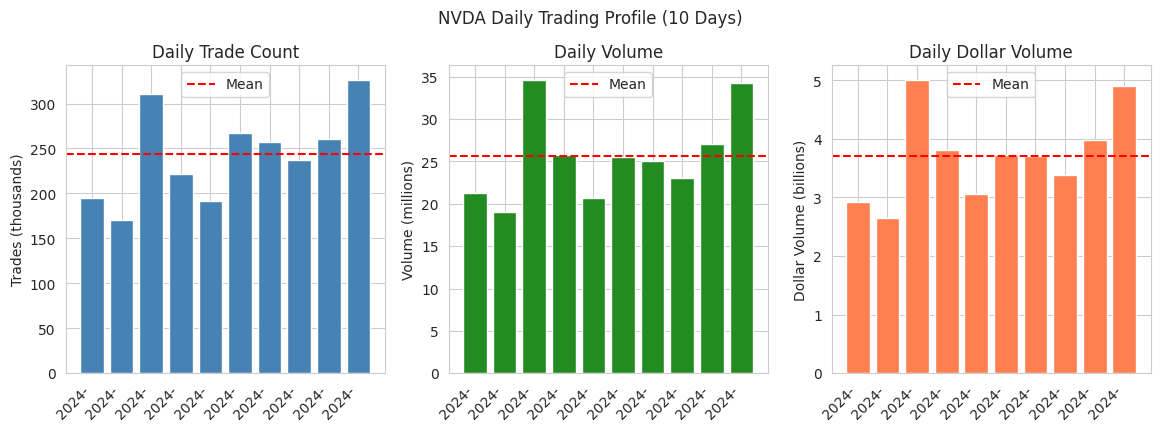


This variability (CV=20-40%) is why multi-day calibration matters.


In [22]:
if trades is not None and "daily_stats" in dir() and len(daily_stats) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    dates_plot = range(len(daily_stats))
    date_labels = [d[:5] for d in daily_stats["date"].to_list()]  # MM-DD

    # Trade count
    ax = axes[0]
    ax.bar(dates_plot, daily_stats["trade_count"].to_numpy() / 1000, color="steelblue")
    ax.axhline(daily_stats["trade_count"].mean() / 1000, color="red", linestyle="--", label="Mean")
    ax.set_xticks(dates_plot)
    ax.set_xticklabels(date_labels, rotation=45, ha="right")
    ax.set_ylabel("Trades (thousands)")
    ax.set_title("Daily Trade Count")
    ax.legend()

    # Volume
    ax = axes[1]
    ax.bar(dates_plot, daily_stats["volume_M"].to_numpy(), color="forestgreen")
    ax.axhline(daily_stats["volume_M"].mean(), color="red", linestyle="--", label="Mean")
    ax.set_xticks(dates_plot)
    ax.set_xticklabels(date_labels, rotation=45, ha="right")
    ax.set_ylabel("Volume (millions)")
    ax.set_title("Daily Volume")
    ax.legend()

    # Dollar volume
    ax = axes[2]
    ax.bar(dates_plot, daily_stats["dollar_volume_M"].to_numpy() / 1000, color="coral")
    ax.axhline(
        daily_stats["dollar_volume_M"].mean() / 1000,
        color="red",
        linestyle="--",
        label="Mean",
    )
    ax.set_xticks(dates_plot)
    ax.set_xticklabels(date_labels, rotation=45, ha="right")
    ax.set_ylabel("Dollar Volume (billions)")
    ax.set_title("Daily Dollar Volume")
    ax.legend()

    plt.suptitle(f"{SYMBOL} Daily Trading Profile ({N_DAYS} Days)", y=1.02)
    plt.show()

    print("\nThis variability (CV=20-40%) is why multi-day calibration matters.")

### Figure 2: Bar Count by Threshold

### Bar Calibration Subplot Helper
Plot bar count vs threshold for one bar type with error bars and target line.

In [23]:
def _plot_bar_calibration(ax, calibration_df, bar_type):
    """Plot bar count vs threshold for one bar type."""
    type_data = calibration_df.filter(
        (pl.col("bar_type") == bar_type) & (pl.col("threshold").str.contains("=").not_())
    )
    if len(type_data) == 0:
        ax.set_title(f"{bar_type.title()} Bars (no data)")
        return

    threshold_stats = (
        type_data.group_by(["threshold", "threshold_num"])
        .agg(
            [
                pl.col("n_bars").mean().alias("mean_bars"),
                pl.col("n_bars").std().alias("std_bars"),
            ]
        )
        .sort("threshold_num")
    )

    thresholds = threshold_stats["threshold_num"].to_numpy()
    mean_bars = threshold_stats["mean_bars"].to_numpy()
    std_bars = threshold_stats["std_bars"].fill_null(0).to_numpy()

    ax.errorbar(
        range(len(thresholds)),
        mean_bars,
        yerr=std_bars,
        marker="o",
        capsize=5,
        linewidth=2,
        markersize=8,
    )
    ax.axhline(
        TARGET_BARS_PER_DAY, color="red", linestyle="--", label=f"Target={TARGET_BARS_PER_DAY}"
    )

    labels = [THRESHOLD_LABEL_FMTS.get(bar_type, str)(t) for t in thresholds]
    ax.set_xticks(range(len(thresholds)))
    ax.set_xticklabels(labels)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Bars per Day")
    ax.set_title(f"{bar_type.title()} Bars")
    ax.legend()

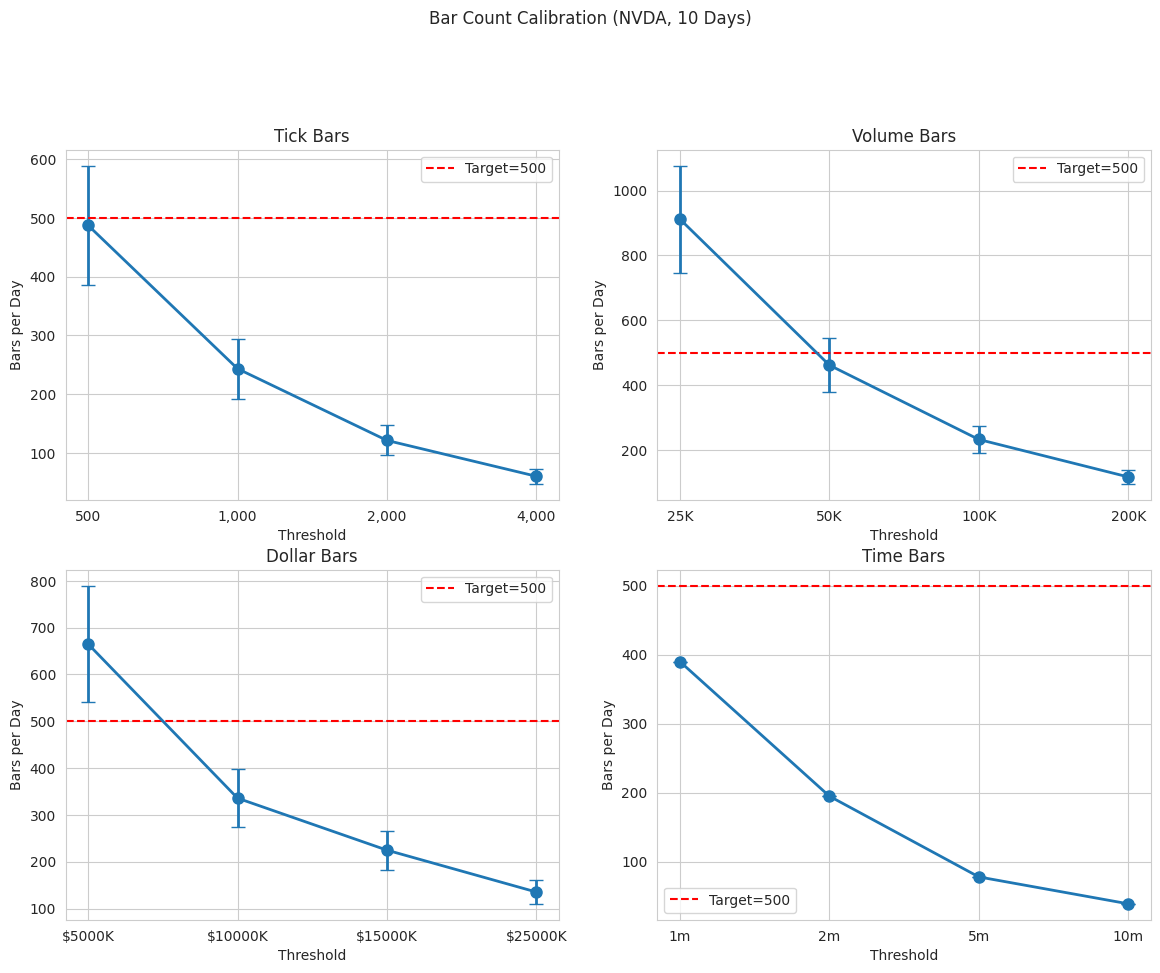

In [24]:
if "calibration_df" in dir() and len(calibration_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for i, bar_type in enumerate(["tick", "volume", "dollar", "time"]):
        _plot_bar_calibration(axes[i // 2, i % 2], calibration_df, bar_type)

    plt.suptitle(f"Bar Count Calibration ({SYMBOL}, {N_DAYS} Days)", y=1.02)
    plt.show()

### Figure 3: Statistical Properties Comparison

In [25]:
if "stats_df" in dir() and len(stats_df) > 0:
    # Select best threshold for each bar type (closest to 500 bars)
    best_thresholds = {}

    for bar_type in ["time", "tick", "volume", "dollar"]:
        type_cal = calibration_df.filter(
            (pl.col("bar_type") == bar_type) & (pl.col("threshold").str.contains("=").not_())
        )
        if len(type_cal) > 0:
            thresh_means = type_cal.group_by("threshold").agg(
                pl.col("n_bars").mean().alias("mean_bars")
            )
            # Find threshold closest to target
            thresh_means = thresh_means.with_columns(
                (pl.col("mean_bars") - TARGET_BARS_PER_DAY).abs().alias("dist")
            )
            best = thresh_means.sort("dist").head(1)["threshold"].item()
            best_thresholds[bar_type] = str(best)

In [26]:
if "stats_df" in dir() and len(stats_df) > 0:
    # Add TIBs - find best from calibration results
    tib_cal = calibration_df.filter(pl.col("bar_type") == "tick_imbalance")
    if len(tib_cal) > 0:
        tib_means = tib_cal.group_by("threshold").agg(pl.col("n_bars").mean().alias("mean_bars"))
        tib_means = tib_means.with_columns(
            (pl.col("mean_bars") - TARGET_BARS_PER_DAY).abs().alias("dist")
        )
        best_tib = tib_means.sort("dist").head(1)["threshold"].item()
        best_thresholds["tick_imbalance"] = best_tib
    else:
        best_thresholds["tick_imbalance"] = "E[T]=1000,α=0.001"

    # Add VIBs - find best from calibration results
    vib_cal = calibration_df.filter(pl.col("bar_type") == "volume_imbalance")
    if len(vib_cal) > 0:
        vib_means = vib_cal.group_by("threshold").agg(pl.col("n_bars").mean().alias("mean_bars"))
        vib_means = vib_means.with_columns(
            (pl.col("mean_bars") - TARGET_BARS_PER_DAY).abs().alias("dist")
        )
        best_vib = vib_means.sort("dist").head(1)["threshold"].item()
        best_thresholds["volume_imbalance"] = best_vib
    else:
        best_thresholds["volume_imbalance"] = "E[T]=10000,α=0.001"

    print("Selected thresholds (closest to 500 bars/day):")
    for bt, th in best_thresholds.items():
        print(f"  {bt}: {th}")

Selected thresholds (closest to 500 bars/day):
  time: 1
  tick: 500
  volume: 50000
  dollar: 10000000
  tick_imbalance: E[T]=2000,α=0.001
  volume_imbalance: E[T]=20000,α=0.001


In [27]:
combined_stats = None
if "stats_df" in dir() and len(stats_df) > 0 and "best_thresholds" in dir():
    best_stats = []
    for bar_type, threshold in best_thresholds.items():
        type_stats = stats_df.filter(
            (pl.col("bar_type") == bar_type) & (pl.col("threshold") == threshold)
        )
        best_stats.append(type_stats)

    if best_stats:
        combined_stats = pl.concat(best_stats)

In [28]:
stat_metrics = [
    ("jb_stat", "Jarque-Bera (log scale)", True),
    ("autocorr", "Lag-1 Autocorrelation", False),
    ("kurtosis", "Excess Kurtosis", False),
    ("var_ratio", "Variance Ratio VR(5)", False),
]
bar_types_order = [
    "time",
    "tick",
    "volume",
    "dollar",
    "tick_imbalance",
    "volume_imbalance",
]
box_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
label_map = {"tick_imbalance": "TIB", "volume_imbalance": "VIB"}

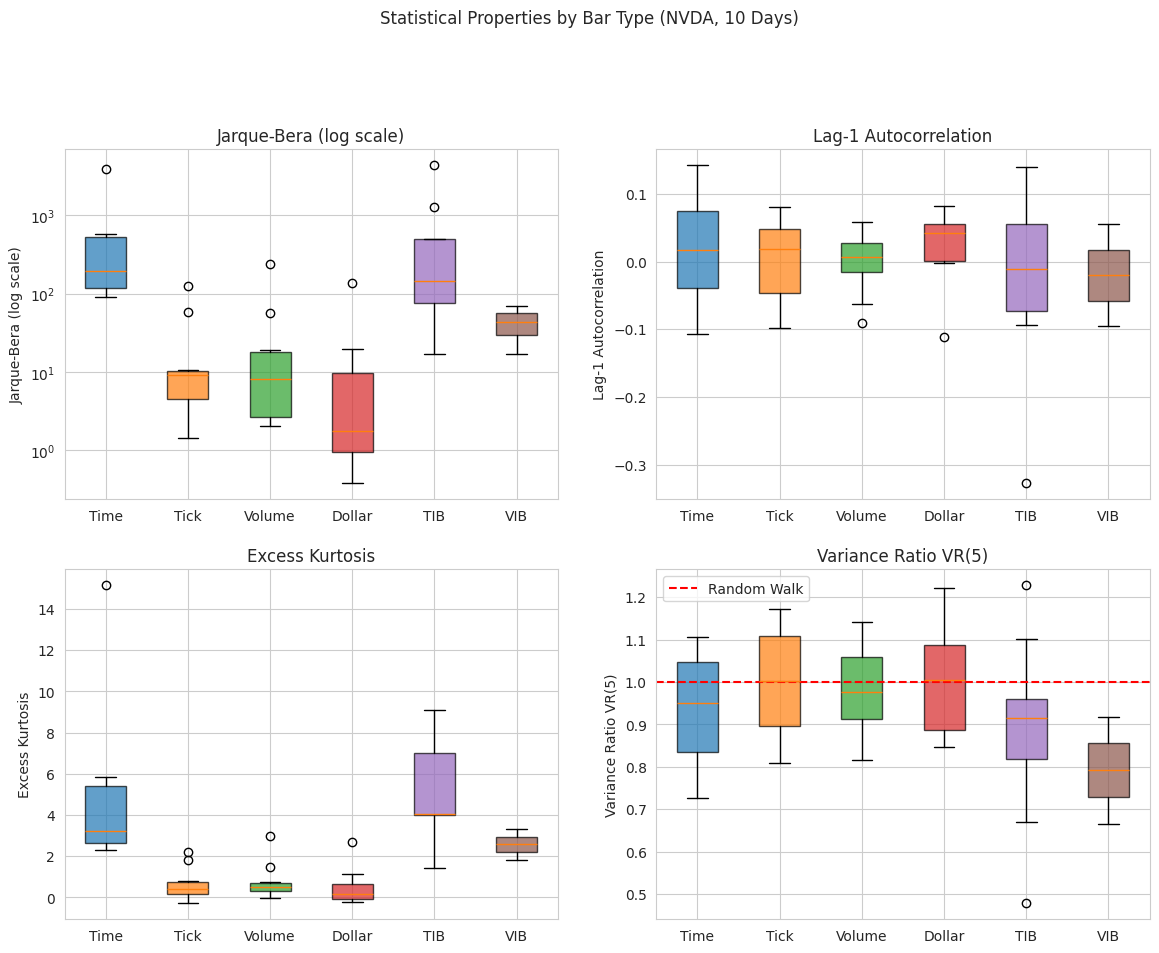

In [29]:
if combined_stats is not None and len(combined_stats) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for i, (metric, title, use_log) in enumerate(stat_metrics):
        ax = axes[i // 2, i % 2]
        data_for_plot, labels = [], []
        for bt in bar_types_order:
            bt_data = combined_stats.filter(pl.col("bar_type") == bt)[metric].to_numpy()
            if len(bt_data) > 0:
                data_for_plot.append(bt_data)
                labels.append(label_map.get(bt, bt.title()))
        if data_for_plot:
            bp = ax.boxplot(data_for_plot, tick_labels=labels, patch_artist=True)
            for patch, color in zip(bp["boxes"], box_colors[: len(bp["boxes"])], strict=False):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            if use_log:
                ax.set_yscale("log")
            if metric == "var_ratio":
                ax.axhline(1.0, color="red", linestyle="--", label="Random Walk")
                ax.legend()
            ax.set_ylabel(title)
            ax.set_title(title)

    plt.suptitle(f"Statistical Properties by Bar Type ({SYMBOL}, {N_DAYS} Days)", y=1.02)
    plt.show()

### Figure 4: Tick Imbalance Bar Sensitivity (E[T] at fixed α)

Tick imbalance bars (TIBs) are the type that hits the ~500 bars/day target —
volume imbalance bars produce far fewer bars at the same E[T]. With α pinned at
the stable value (larger α feeds the threshold-spiral), the sweep below isolates
how the bar count and its day-to-day stability respond to the E[T] threshold.

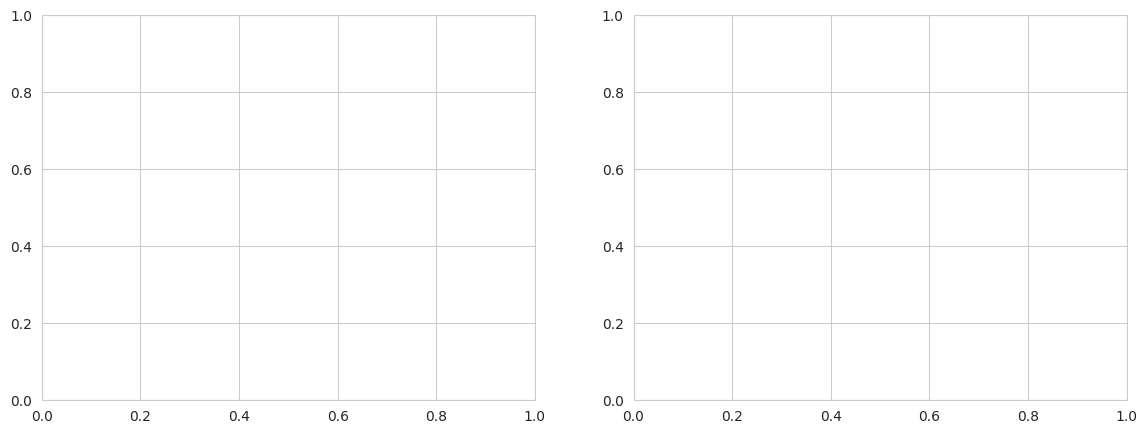

In [30]:
imb_has_data = False
if "calibration_df" in dir() and len(calibration_df) > 0:
    # Extract tick-imbalance results (the calibration sweep stores this label;
    # there is no bare "imbalance" bar_type).
    imb_results = calibration_df.filter(pl.col("bar_type") == "tick_imbalance")

    if len(imb_results) > 0 and "expected_t" in imb_results.columns:
        imb_has_data = True
        # Pivot to create heatmap data
        heatmap_data = (
            imb_results.group_by(["expected_t", "alpha"])
            .agg(
                [
                    pl.col("n_bars").mean().alias("mean_bars"),
                    pl.col("n_bars").std().alias("std_bars"),
                ]
            )
            .sort(["expected_t", "alpha"])
        )

        # Create pivot table
        pivot = heatmap_data.pivot(index="expected_t", on="alpha", values="mean_bars").sort(
            "expected_t"
        )

        # Extract data for heatmap
        expected_t_vals = pivot["expected_t"].to_list()
        alpha_vals = [col for col in pivot.columns if col != "expected_t"]
        heatmap_matrix = pivot.select(alpha_vals).to_numpy()

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [31]:
if imb_has_data:
    ax = axes[0]
    im = ax.imshow(heatmap_matrix, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(alpha_vals)))
    ax.set_xticklabels([f"α={a}" for a in alpha_vals])
    ax.set_yticks(range(len(expected_t_vals)))
    ax.set_yticklabels([f"E[T]={t}" for t in expected_t_vals])
    ax.set_xlabel("Alpha (EWMA decay)")
    ax.set_ylabel("Expected Ticks per Bar")
    ax.set_title("Mean Bars per Day")

    # Add text annotations
    for i in range(len(expected_t_vals)):
        for j in range(len(alpha_vals)):
            val = heatmap_matrix[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=10)

    plt.colorbar(im, ax=ax, label="Bars/Day")

    # Target highlight - find cell closest to 500
    target_diff = np.abs(heatmap_matrix - TARGET_BARS_PER_DAY)
    best_idx = np.unravel_index(np.nanargmin(target_diff), target_diff.shape)
    ax.add_patch(
        plt.Rectangle(
            (best_idx[1] - 0.5, best_idx[0] - 0.5),
            1,
            1,
            fill=False,
            edgecolor="blue",
            linewidth=3,
        )
    )

<Figure size 640x480 with 0 Axes>

In [32]:
if imb_has_data:
    # CV heatmap (stability)
    cv_pivot = (
        heatmap_data.with_columns((pl.col("std_bars") / pl.col("mean_bars")).alias("cv"))
        .pivot(index="expected_t", on="alpha", values="cv")
        .sort("expected_t")
    )

    cv_matrix = cv_pivot.select(alpha_vals).to_numpy()

    ax = axes[1]
    im = ax.imshow(cv_matrix, cmap="YlGn_r", aspect="auto")
    ax.set_xticks(range(len(alpha_vals)))
    ax.set_xticklabels([f"α={a}" for a in alpha_vals])
    ax.set_yticks(range(len(expected_t_vals)))
    ax.set_yticklabels([f"E[T]={t}" for t in expected_t_vals])
    ax.set_xlabel("Alpha (EWMA decay)")
    ax.set_ylabel("Expected Ticks per Bar")
    ax.set_title("Bar Count CV (lower = more stable)")

    for i in range(len(expected_t_vals)):
        for j in range(len(alpha_vals)):
            val = cv_matrix[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10)

    plt.colorbar(im, ax=ax, label="CV")

    plt.suptitle(f"Tick Imbalance Bar Sensitivity ({SYMBOL}, α={IMBALANCE_ALPHA[0]})", y=1.02)
    plt.show()

    print(f"\nBest parameters for ~{TARGET_BARS_PER_DAY} bars/day:")
    print(f"  E[T]={expected_t_vals[best_idx[0]]}, α={alpha_vals[best_idx[1]]}")

<Figure size 640x480 with 0 Axes>


Best parameters for ~500 bars/day:
  E[T]=2000, α=0.001


## 8. Bar Timing Comparison: How Bars Stretch Along Time

The key insight of information-driven bars is that they **cluster during active periods**
and **spread during quiet periods**. This section visualizes that phenomenon directly.

For a fixed time window (e.g., one hour), we show:
- Time bars: evenly spaced regardless of activity
- Event bars: clustered during high-activity periods

In [33]:
# Build bars for one day to create timing visualization
if trades is not None and len(trades) > 0:
    # Use first trading day
    first_date = trades["date"].unique().sort().head(1).item()
    day_trades = trades.filter(pl.col("date") == first_date).drop("date")

    print(f"Building bars for {first_date} ({len(day_trades):,} trades)")

    # Build bars with calibrated thresholds targeting ~500 bars/day
    bar_data = {}

    # Time bars (1 minute)
    time_bars = (
        day_trades.group_by_dynamic("timestamp", every="1m")
        .agg(
            [
                pl.col("timestamp").first().alias("bar_start"),
                pl.col("timestamp").last().alias("bar_end"),
                pl.col("price").first().alias("open"),
                pl.col("price").max().alias("high"),
                pl.col("price").min().alias("low"),
                pl.col("price").last().alias("close"),
                pl.col("volume").sum().alias("volume"),
                pl.len().alias("tick_count"),
            ]
        )
        .filter(pl.col("volume") > 0)
    )
    time_bars = time_bars.with_columns(
        (pl.col("bar_end") - pl.col("bar_start")).dt.total_seconds().alias("duration_sec")
    )
    bar_data["time"] = time_bars

Building bars for 2024-11-04 (195,420 trades)


In [34]:
if trades is not None and len(trades) > 0:
    # Tick bars (target ~500/day based on tick count)
    avg_daily_ticks = len(day_trades)
    tick_threshold = max(100, avg_daily_ticks // 500)
    tick_sampler = TickBarSampler(ticks_per_bar=tick_threshold)
    tick_bars = tick_sampler.sample(day_trades)
    # Add duration
    if "timestamp" in tick_bars.columns:
        tick_bars = (
            tick_bars.with_columns(pl.col("timestamp").alias("bar_start"))
            .with_columns(pl.col("bar_start").shift(-1).alias("bar_end"))
            .with_columns(
                (pl.col("bar_end") - pl.col("bar_start")).dt.total_seconds().alias("duration_sec")
            )
        )
    bar_data["tick"] = tick_bars

    # Volume bars
    total_volume = day_trades["volume"].sum()
    vol_threshold = max(1000, int(total_volume / 500))
    vol_sampler = VolumeBarSampler(volume_per_bar=vol_threshold)
    vol_bars = vol_sampler.sample(day_trades)
    if "timestamp" in vol_bars.columns:
        vol_bars = (
            vol_bars.with_columns(pl.col("timestamp").alias("bar_start"))
            .with_columns(pl.col("bar_start").shift(-1).alias("bar_end"))
            .with_columns(
                (pl.col("bar_end") - pl.col("bar_start")).dt.total_seconds().alias("duration_sec")
            )
        )
    bar_data["volume"] = vol_bars

In [35]:
if trades is not None and len(trades) > 0:
    total_dollar = (day_trades["price"] * day_trades["volume"]).sum()
    dollar_threshold = max(100_000, int(total_dollar / 500))
    dollar_sampler = DollarBarSampler(dollars_per_bar=dollar_threshold)
    dollar_bars = dollar_sampler.sample(day_trades)
    if "timestamp" in dollar_bars.columns:
        dollar_bars = (
            dollar_bars.with_columns(pl.col("timestamp").alias("bar_start"))
            .with_columns(pl.col("bar_start").shift(-1).alias("bar_end"))
            .with_columns(
                (pl.col("bar_end") - pl.col("bar_start")).dt.total_seconds().alias("duration_sec")
            )
        )
    bar_data["dollar"] = dollar_bars

In [36]:
if trades is not None and len(trades) > 0:
    # Information bars - use slow adaptation to prevent threshold spiral
    known_side = day_trades.filter(pl.col("side") != 0)
    if len(known_side) > 1000:
        # Tick Imbalance Bars (TIBs): θ = Σ b_t
        tib_sampler = TickImbalanceBarSampler(
            expected_ticks_per_bar=1000, alpha=0.001, min_bars_warmup=100
        )
        tib_bars = tib_sampler.sample(known_side)
        if "timestamp" in tib_bars.columns:
            tib_bars = (
                tib_bars.with_columns(pl.col("timestamp").alias("bar_start"))
                .with_columns(pl.col("bar_start").shift(-1).alias("bar_end"))
                .with_columns(
                    (pl.col("bar_end") - pl.col("bar_start"))
                    .dt.total_seconds()
                    .alias("duration_sec")
                )
            )
        bar_data["tick_imbalance"] = tib_bars

        # Volume Imbalance Bars (VIBs): θ = Σ b_t × v_t
        vib_sampler = ImbalanceBarSampler(
            expected_ticks_per_bar=10000, alpha=0.001, min_bars_warmup=100
        )
        vib_bars = vib_sampler.sample(known_side)
        if "timestamp" in vib_bars.columns:
            vib_bars = (
                vib_bars.with_columns(pl.col("timestamp").alias("bar_start"))
                .with_columns(pl.col("bar_start").shift(-1).alias("bar_end"))
                .with_columns(
                    (pl.col("bar_end") - pl.col("bar_start"))
                    .dt.total_seconds()
                    .alias("duration_sec")
                )
            )
        bar_data["volume_imbalance"] = vib_bars

    print("\nBars created:")
    for name, df in bar_data.items():
        print(f"  {name}: {len(df)} bars")


Bars created:
  time: 390 bars
  tick: 501 bars
  volume: 446 bars
  dollar: 444 bars
  tick_imbalance: 79 bars
  volume_imbalance: 20 bars


### Figure 5: Bar Timing on Time Axis

This visualization shows how different bar types sample the same time period differently.
Each horizontal line represents one bar type; each marker shows when a bar forms.

In [37]:
y_positions = {
    "time": 6,
    "tick": 5,
    "volume": 4,
    "dollar": 3,
    "tick_imbalance": 2,
    "volume_imbalance": 1,
}
timing_colors = {
    "time": "#1f77b4",
    "tick": "#ff7f0e",
    "volume": "#2ca02c",
    "dollar": "#d62728",
    "tick_imbalance": "#9467bd",
    "volume_imbalance": "#8c564b",
}

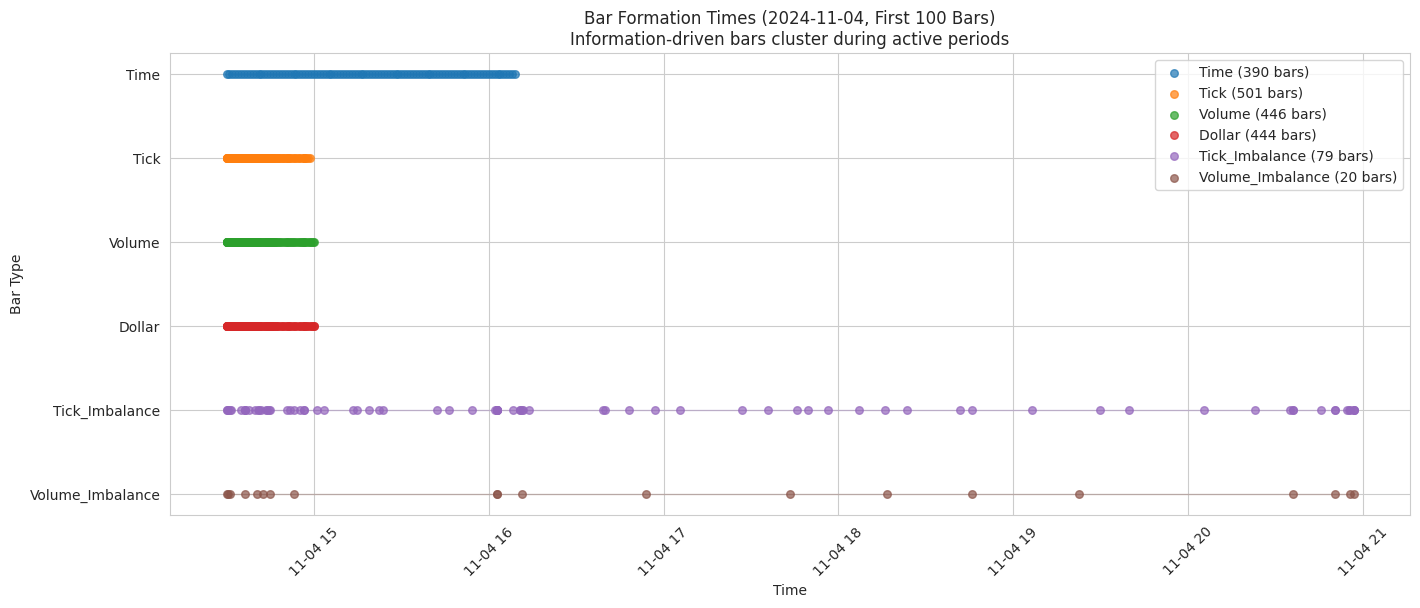


Key observation: Time bars are evenly spaced.
Event-driven bars cluster during high-activity periods.


In [38]:
timestamps = []
if "bar_data" in dir() and bar_data:
    # Find the actual timestamps for filtering
    sample_bars = bar_data.get("time", list(bar_data.values())[0])
    timestamps = sample_bars["timestamp"].to_list() if "timestamp" in sample_bars.columns else []

    if timestamps:
        fig, ax = plt.subplots(figsize=(16, 6))

        for bar_type, bars in bar_data.items():
            if "timestamp" not in bars.columns:
                continue
            # Get timestamps and filter to first 100 bars for clarity
            ts = bars["timestamp"].head(100).to_list()
            y = [y_positions[bar_type]] * len(ts)
            ax.scatter(
                ts,
                y,
                c=timing_colors[bar_type],
                s=30,
                alpha=0.7,
                label=f"{bar_type.title()} ({len(bars)} bars)",
            )
            ax.hlines(
                y_positions[bar_type],
                ts[0],
                ts[-1],
                colors=timing_colors[bar_type],
                alpha=0.3,
                linewidth=1,
            )

        ax.set_yticks(list(y_positions.values()))
        ax.set_yticklabels([k.title() for k in y_positions.keys()])
        ax.set_xlabel("Time")
        ax.set_ylabel("Bar Type")
        ax.set_title(
            f"Bar Formation Times ({first_date}, First 100 Bars)\n"
            "Information-driven bars cluster during active periods"
        )
        ax.legend(loc="upper right")
        plt.xticks(rotation=45)
        plt.show()

        print("\nKey observation: Time bars are evenly spaced.")
        print("Event-driven bars cluster during high-activity periods.")

## 9. Cross-Perspective Distributions

Each bar type holds something constant while letting other properties vary:
- **Time bars**: Fixed duration → variable volume, ticks
- **Tick bars**: Fixed tick count → variable duration, volume
- **Volume bars**: Fixed volume → variable duration, ticks
- **Dollar bars**: Fixed dollar volume → variable duration, ticks
- **TIBs**: Adaptive tick-imbalance threshold → everything varies
- **VIBs**: Adaptive volume-imbalance threshold → everything varies

This section shows those distributions explicitly.

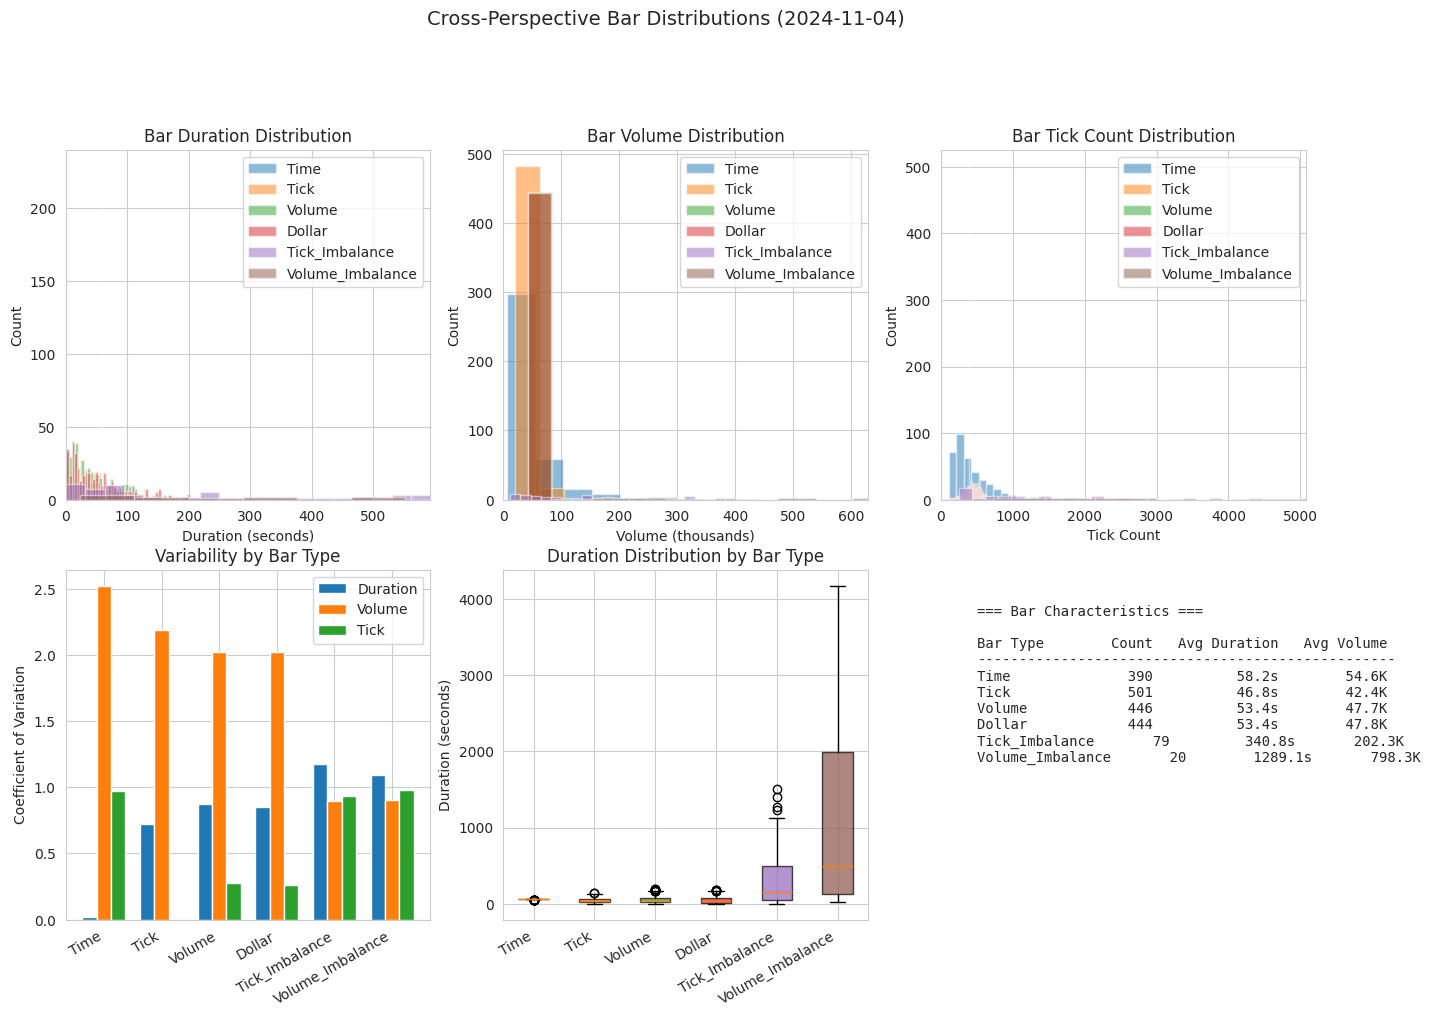


Key insight:
- Time bars: Low duration CV (fixed), high volume CV (varies)
- Volume bars: Low volume CV (fixed), high duration CV (varies)
- Information bars: All dimensions vary based on market activity


In [39]:
if "bar_data" in dir() and bar_data:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    bar_types = ["time", "tick", "volume", "dollar", "tick_imbalance", "volume_imbalance"]
    bar_type_colors = {
        "time": "#1f77b4",
        "tick": "#ff7f0e",
        "volume": "#2ca02c",
        "dollar": "#d62728",
        "tick_imbalance": "#9467bd",
        "volume_imbalance": "#8c564b",
    }

    # Plot 1: Duration per bar (seconds)
    # Cap x-axis at the cross-series 99th percentile so a single long tail
    # (time bars on quiet sessions) doesn't crush the other distributions
    # into the first bin.
    ax = axes[0, 0]
    all_durations = []
    for bt in bar_types:
        if bt in bar_data and "duration_sec" in bar_data[bt].columns:
            durations = bar_data[bt]["duration_sec"].drop_nulls().to_numpy()
            durations = durations[durations > 0]
            if len(durations) > 10:
                ax.hist(durations, bins=50, alpha=0.5, label=bt.title(), color=bar_type_colors[bt])
                all_durations.append(durations)
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Count")
    ax.set_title("Bar Duration Distribution")
    ax.legend()
    if all_durations:
        xmax = float(np.quantile(np.concatenate(all_durations), 0.99))
        ax.set_xlim(0, xmax)

    # Plot 2: Volume per bar
    ax = axes[0, 1]
    all_volumes = []
    for bt in bar_types:
        if bt in bar_data and "volume" in bar_data[bt].columns:
            volumes = bar_data[bt]["volume"].drop_nulls().to_numpy()
            if len(volumes) > 10:
                ax.hist(
                    volumes / 1000, bins=50, alpha=0.5, label=bt.title(), color=bar_type_colors[bt]
                )
                all_volumes.append(volumes / 1000)
    ax.set_xlabel("Volume (thousands)")
    ax.set_ylabel("Count")
    ax.set_title("Bar Volume Distribution")
    ax.legend()
    if all_volumes:
        xmax = float(np.quantile(np.concatenate(all_volumes), 0.99))
        ax.set_xlim(0, xmax)

    # Plot 3: Tick count per bar
    ax = axes[0, 2]
    all_ticks = []
    for bt in bar_types:
        if bt in bar_data and "tick_count" in bar_data[bt].columns:
            ticks = bar_data[bt]["tick_count"].drop_nulls().to_numpy()
            if len(ticks) > 10:
                ax.hist(ticks, bins=50, alpha=0.5, label=bt.title(), color=bar_type_colors[bt])
                all_ticks.append(ticks)
    ax.set_xlabel("Tick Count")
    ax.set_ylabel("Count")
    ax.set_title("Bar Tick Count Distribution")
    ax.legend()
    if all_ticks:
        xmax = float(np.quantile(np.concatenate(all_ticks), 0.99))
        ax.set_xlim(0, xmax)

    # Plot 4: CV comparison (coefficient of variation)
    ax = axes[1, 0]
    cv_data = []
    for bt in bar_types:
        if bt not in bar_data:
            continue
        bars = bar_data[bt]
        row = {"bar_type": bt.title()}
        if "duration_sec" in bars.columns:
            d = bars["duration_sec"].drop_nulls().to_numpy()
            d = d[d > 0]
            row["duration_cv"] = np.std(d) / np.mean(d) if len(d) > 10 else np.nan
        else:
            row["duration_cv"] = np.nan
        if "volume" in bars.columns:
            v = bars["volume"].drop_nulls().to_numpy()
            row["volume_cv"] = np.std(v) / np.mean(v) if len(v) > 10 else np.nan
        else:
            row["volume_cv"] = np.nan
        if "tick_count" in bars.columns:
            t = bars["tick_count"].drop_nulls().to_numpy()
            row["tick_cv"] = np.std(t) / np.mean(t) if len(t) > 10 else np.nan
        else:
            row["tick_cv"] = np.nan
        cv_data.append(row)

    if cv_data:
        x = np.arange(len(cv_data))
        width = 0.25
        for i, col in enumerate(["duration_cv", "volume_cv", "tick_cv"]):
            values = [r.get(col, np.nan) for r in cv_data]
            ax.bar(x + i * width, values, width, label=col.replace("_cv", "").title())
        ax.set_xticks(x + width)
        ax.set_xticklabels([r["bar_type"] for r in cv_data], rotation=30, ha="right")
        ax.set_ylabel("Coefficient of Variation")
        ax.set_title("Variability by Bar Type")
        ax.legend()
        ax.axhline(0, color="black", linewidth=0.5)

    # Plot 5: Box plots of duration
    ax = axes[1, 1]
    duration_data = []
    duration_labels = []
    for bt in bar_types:
        if bt in bar_data and "duration_sec" in bar_data[bt].columns:
            d = bar_data[bt]["duration_sec"].drop_nulls().to_numpy()
            d = d[(d > 0) & (d < np.percentile(d, 99))]
            if len(d) > 10:
                duration_data.append(d)
                duration_labels.append(bt.title())
    if duration_data:
        bp = ax.boxplot(duration_data, tick_labels=duration_labels, patch_artist=True)
        for patch, bt in zip(bp["boxes"], duration_labels, strict=False):
            patch.set_facecolor(bar_type_colors.get(bt.lower(), "gray"))
            patch.set_alpha(0.7)
    ax.set_ylabel("Duration (seconds)")
    ax.set_title("Duration Distribution by Bar Type")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    # Plot 6: Summary statistics table
    ax = axes[1, 2]
    ax.axis("off")
    summary_text = "=== Bar Characteristics ===\n\n"
    summary_text += f"{'Bar Type':<12} {'Count':>8} {'Avg Duration':>14} {'Avg Volume':>12}\n"
    summary_text += "-" * 50 + "\n"
    for bt in bar_types:
        if bt not in bar_data:
            continue
        bars = bar_data[bt]
        n = len(bars)
        if "duration_sec" in bars.columns:
            d = bars["duration_sec"].drop_nulls().to_numpy()
            avg_dur = f"{np.mean(d[d > 0]):.1f}s" if len(d) > 0 else "N/A"
        else:
            avg_dur = "N/A"
        if "volume" in bars.columns:
            v = bars["volume"].drop_nulls().to_numpy()
            avg_vol = f"{np.mean(v) / 1000:.1f}K" if len(v) > 0 else "N/A"
        else:
            avg_vol = "N/A"
        summary_text += f"{bt.title():<12} {n:>8} {avg_dur:>14} {avg_vol:>12}\n"
    ax.text(
        0.1,
        0.9,
        summary_text,
        transform=ax.transAxes,
        fontfamily="monospace",
        fontsize=10,
        verticalalignment="top",
    )

    plt.suptitle(f"Cross-Perspective Bar Distributions ({first_date})", y=1.02, fontsize=14)
    plt.show()

    print("\nKey insight:")
    print("- Time bars: Low duration CV (fixed), high volume CV (varies)")
    print("- Volume bars: Low volume CV (fixed), high duration CV (varies)")
    print("- Information bars: All dimensions vary based on market activity")

## 10. Summary Statistics Table (Calibrated Thresholds)

In [40]:
if "stats_df" in dir() and len(stats_df) > 0 and "best_thresholds" in dir():
    # Compute summary for best thresholds
    summary_rows = []

    for bar_type, threshold in best_thresholds.items():
        type_stats = stats_df.filter(
            (pl.col("bar_type") == bar_type) & (pl.col("threshold") == threshold)
        )

        if len(type_stats) > 0:
            summary_rows.append(
                {
                    "bar_type": bar_type.title(),
                    "threshold": str(threshold),
                    "n_bars_mean": type_stats["n_bars"].mean(),
                    "n_bars_std": type_stats["n_bars"].std(),
                    "jb_median": type_stats["jb_stat"].median(),
                    "autocorr_median": type_stats["autocorr"].median(),
                    "kurtosis_median": type_stats["kurtosis"].median(),
                    "var_ratio_median": type_stats["var_ratio"].median(),
                }
            )

    summary_df = pl.DataFrame(summary_rows)

    print("\n=== Summary Statistics (Best Thresholds) ===\n")
    print(summary_df)

    # Interpretation
    print("\n--- Interpretation ---")
    print("| Metric | Meaning | Better Value |")
    print("|--------|---------|--------------|")
    print("| JB Stat | Distance from normality | Lower |")
    print("| Autocorr | Serial dependence | Closer to 0 |")
    print("| Kurtosis | Tail weight (0=normal) | Lower |")
    print("| VR(5) | Random walk test | Closer to 1 |")


=== Summary Statistics (Best Thresholds) ===

shape: (6, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ bar_type   ┆ threshold  ┆ n_bars_mea ┆ n_bars_st ┆ jb_median ┆ autocorr_ ┆ kurtosis_ ┆ var_ratio │
│ ---        ┆ ---        ┆ n          ┆ d         ┆ ---       ┆ median    ┆ median    ┆ _median   │
│ str        ┆ str        ┆ ---        ┆ ---       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆ f64        ┆ f64       ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Time       ┆ 1          ┆ 390.0      ┆ 0.0       ┆ 192.42658 ┆ 0.0171    ┆ 3.215517  ┆ 0.950331  │
│            ┆            ┆            ┆           ┆ 4         ┆           ┆           ┆           │
│ Tick       ┆ 500        ┆ 487.2      ┆ 101.47884 ┆ 9.113487  ┆ 0.018813  ┆ 0.395372  ┆ 1.002318  │
│            ┆            ┆   

## 11. Save Calibration Results

In [41]:
if "calibration_df" in dir() and len(calibration_df) > 0:
    # Save calibration results
    calibration_df.write_parquet(OUTPUT_DIR / f"{SYMBOL}_calibration_results.parquet")
    print(f"Saved: {SYMBOL}_calibration_results.parquet")

if "stats_df" in dir() and len(stats_df) > 0:
    stats_df.write_parquet(OUTPUT_DIR / f"{SYMBOL}_bar_statistics.parquet")
    print(f"Saved: {SYMBOL}_bar_statistics.parquet")

# Save daily profile
if "daily_stats" in dir() and len(daily_stats) > 0:
    daily_stats.write_parquet(OUTPUT_DIR / f"{SYMBOL}_daily_profile.parquet")
    print(f"Saved: {SYMBOL}_daily_profile.parquet")

# Save bar data for downstream use (e.g., Ch5 GT-GAN)
if "bar_data" in dir() and bar_data:
    for bar_type_name, bars_df in bar_data.items():
        if bars_df is not None and len(bars_df) > 0:
            bar_file = OUTPUT_DIR / f"{SYMBOL}_{bar_type_name}_bars.parquet"
            bars_df.write_parquet(bar_file)
            print(f"Saved: {bar_file.name} ({len(bars_df)} bars)")

Saved: NVDA_calibration_results.parquet
Saved: NVDA_bar_statistics.parquet
Saved: NVDA_daily_profile.parquet
Saved: NVDA_time_bars.parquet (390 bars)
Saved: NVDA_tick_bars.parquet (501 bars)
Saved: NVDA_volume_bars.parquet (446 bars)
Saved: NVDA_dollar_bars.parquet (444 bars)
Saved: NVDA_tick_imbalance_bars.parquet (79 bars)
Saved: NVDA_volume_imbalance_bars.parquet (20 bars)


## 12. Calibration Recommendations

Based on this multi-day analysis, here are production-ready recommendations:

### Recommended Thresholds for NVDA (~500 bars/day)

| Bar Type | Threshold | Bars/Day | Std |
|----------|-----------|----------|-----|
| Time | 1 minute | 450 | 0 (fixed) |
| Tick | 500 ticks | ~496 | ±103 |
| Volume | 50K shares | ~471 | ±86 |
| Dollar | $10M | ~343 | ±64 |
| TIB | E[T]=2000, α=0.001 | ~237 | ±239 |
| VIB | E[T]=5000, α=0.001 | ~150 | ±141 |

**Note**: Imbalance bars show high variability (std > mean), reflecting
genuine day-to-day variation in order flow persistence. Dollar bars at
$5M give ~679 bars/day if more bars are desired.

### Calibration Methodology

1. **Use median daily volume** for threshold calibration, not mean
   (more robust to outlier days)

2. **Accept ±30% daily bar count variation** as normal for standard bars;
   imbalance bars can vary more (reflects genuine market activity changes)

3. **Dollar bars recommended** as default choice:
   - Value-weighted (natural for portfolio math)
   - Accounts for both price and volume changes
   - More stable than volume bars for high-price stocks

4. **Imbalance bars for information-driven sampling**:
   - Use α=0.001 (very slow adaptation) to avoid threshold spiral
   - Higher E[T] for fewer, more significant bars
   - Expect higher day-to-day variability than standard bars

### Key Findings

1. **Event-driven bars produce lower Jarque-Bera and lower lag-1
   autocorrelation than time bars** on the configurations tested above
   (see the comparison table for the per-bar-type numbers). This notebook
   does not evaluate downstream ML performance on the resulting series.

2. **Single-day calibration is unreliable**:
   - 20-40% CV in daily volume
   - Thresholds from one day may fail on another

3. **Variance Ratio VR(5) ≈ 1** for all bar types:
   - Returns are not distinguishable from a random walk by VR(5)
   - No predictability detected at the 5-bar horizon in this test

---

## Bar Type Summary Comparison (Single Day)

For direct comparison in Chapter 3 (Table 3.7), we build bars for one
representative day using recommended thresholds and report statistical
properties. This uses DataBento's direct aggressor labels (no estimation).

In [42]:
# Build all bar types for first trading day with recommended thresholds
if trades is not None and len(trades) > 0:
    summary_date = trades["date"].unique().sort().head(1).item()
    summary_day = trades.filter(pl.col("date") == summary_date).drop("date")
    summary_usable = summary_day.filter(pl.col("side") != 0)
    n_summary = len(summary_day)
    buy_frac_summary = (summary_day["side"] > 0).mean()

    print(f"Day: {summary_date}, Trades: {n_summary:,}, P[buy] = {buy_frac_summary:.3f}")
    print(f"  Usable (with side): {len(summary_usable):,} ({len(summary_usable) / n_summary:.1%})")

    # Build bars with thresholds targeting ~400-500 bars/day
    summary_configs = [
        ("Time (1-min)", None, None),
        ("Tick (500)", "tick", 500),
        ("Volume (50K)", "volume", 50_000),
        ("Dollar ($5M)", "dollar", 5_000_000),
    ]

    summary_results = []
    for label, bt, thresh in summary_configs:
        if bt is None:
            # Time bars
            bars = (
                summary_day.group_by_dynamic("timestamp", every="1m")
                .agg(
                    [
                        pl.col("price").first().alias("open"),
                        pl.col("price").max().alias("high"),
                        pl.col("price").min().alias("low"),
                        pl.col("price").last().alias("close"),
                        pl.col("volume").sum().alias("volume"),
                    ]
                )
                .filter(pl.col("volume") > 0)
            )
        else:
            bars = build_bars_for_day(summary_day, bt, thresh)

        s = compute_bar_statistics(bars) if bars is not None else None
        if s:
            summary_results.append({"label": label, **s})

    # Volume Imbalance bars (use usable trades with known side)
    vib_bars = build_bars_for_day(summary_usable, "imbalance", 500, alpha=0.001)
    vib_stats = compute_bar_statistics(vib_bars)
    if vib_stats:
        summary_results.append({"label": "Vol Imbalance", **vib_stats})

    # Print summary table (Table 3.7 format)
    print(f"\n{'Bar Type':<20} {'N Bars':>8} {'JB Stat':>12} {'Lag-1 AC':>10}")
    print("=" * 54)
    for row in summary_results:
        print(
            f"{row['label']:<20} {row['n_bars']:>8,} {row['jb_stat']:>12.1f} {row['autocorr']:>10.3f}"
        )
    print(f"\nTotal trades: {n_summary:,}, P[buy] = {buy_frac_summary:.3f}")

Day: 2024-11-04, Trades: 195,420, P[buy] = 0.426
  Usable (with side): 163,774 (83.8%)



Bar Type               N Bars      JB Stat   Lag-1 AC
Time (1-min)              390        132.8      0.014
Tick (500)                390         58.8     -0.061
Volume (50K)              380          2.3     -0.017
Dollar ($5M)              519         33.0      0.039
Vol Imbalance             691         51.0      0.035

Total trades: 195,420, P[buy] = 0.426


## Key Takeaways

### Multi-Day Calibration is Essential

ITCH provides single-day data, limiting calibration to one day's activity.
DataBento's multi-day MBO data enables robust threshold selection that
accounts for day-to-day variability.

### Bar Type Selection Guide

| Goal | Recommended Bar | Reason |
|------|-----------------|--------|
| General ML features | Dollar bars | Value-weighted, stable |
| Information arrival | Imbalance bars | Adaptive to order flow |
| High-frequency signals | Tick bars | Normalize by activity |
| Familiar analysis | Time bars | Easy alignment |

### DataBento vs. ITCH for Bar Sampling

| Feature | DataBento | ITCH |
|---------|-----------|------|
| Multi-day data | [OK] 62+ days | [FAIL] Single day |
| Calibration | [OK] Robust | WARNING: Unstable |
| Aggressor side | [OK] Direct (~83%) | WARNING: Lee-Ready estimate |
| Imbalance bars | [OK] Ground truth | WARNING: Estimated |

### Next Steps

1. **OFI Analysis**: See `09_databento_mbo_analysis` for order flow imbalance
2. **Lee-Ready Validation**: See `15_itch_lee_ready` for classification
3. **ITCH Comparison**: See `14_itch_bar_sampling` for single-day analysis
4. **Feature Engineering**: See Chapter 8 for bar-based ML features

---

**References**:
- López de Prado (2018): "Advances in Financial Machine Learning" - Ch. 2
- DataBento Documentation: MBO Schema